In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

from sklearn.model_selection import train_test_split
from sklearn.linear_model   import LogisticRegression
from sklearn.tree           import DecisionTreeClassifier
from sklearn.ensemble       import RandomForestClassifier
from sklearn.metrics        import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.pipeline       import Pipeline
from sklearn.compose        import ColumnTransformer
from sklearn.preprocessing  import StandardScaler, OneHotEncoder
from sklearn.impute         import SimpleImputer

# Single reproducibility seed used throughout the notebook
RANDOM_STATE = 42

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


In [3]:
df = pd.read_csv("Telco-Customer-Churn.csv")

print("Original shape:", df.shape)
display(df.head())
print(df.info())

Original shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
print("Missing values by column:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Missing values by column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate rows: 0

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling   

In [ ]:
# Convert TotalCharges to numeric (non-numeric entries → NaN)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Drop customerID (identifier, not a predictive feature)
df = df.drop("customerID", axis=1)

# Note: NaN imputation is intentionally deferred to the preprocessing pipeline
# so it is fitted on the training set only (no data leakage).
print("Shape after cleaning:", df.shape)
print("Missing values per column:\n", df.isna().sum()[df.isna().sum() > 0])
print()
print(df.dtypes)


In [6]:
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True))

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


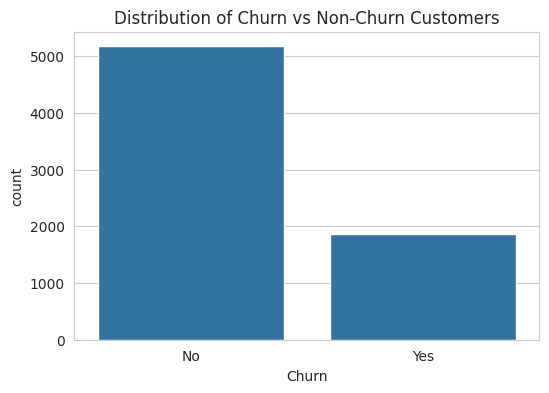

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Churn")
plt.title("Distribution of Churn vs Non-Churn Customers")
plt.show()

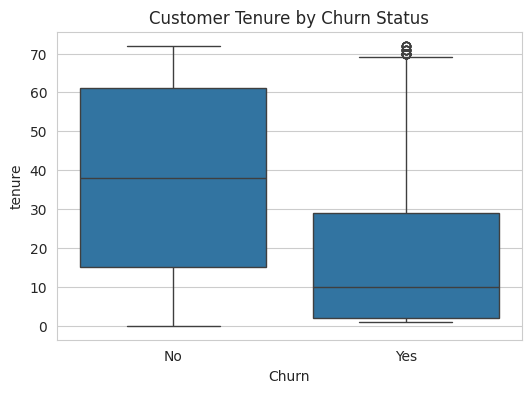

In [8]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Customer Tenure by Churn Status")
plt.show()

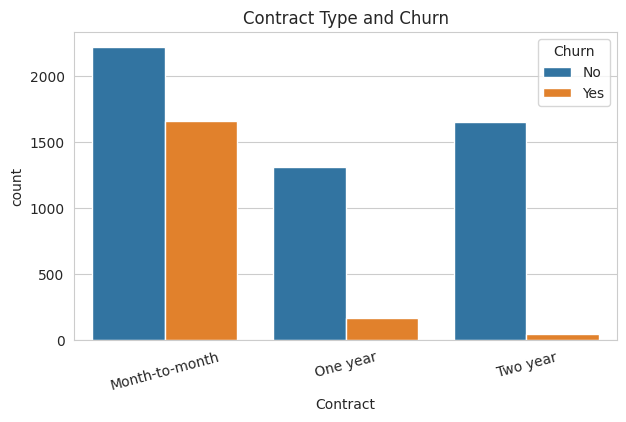

In [9]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Contract Type and Churn")
plt.xticks(rotation=15)
plt.show()

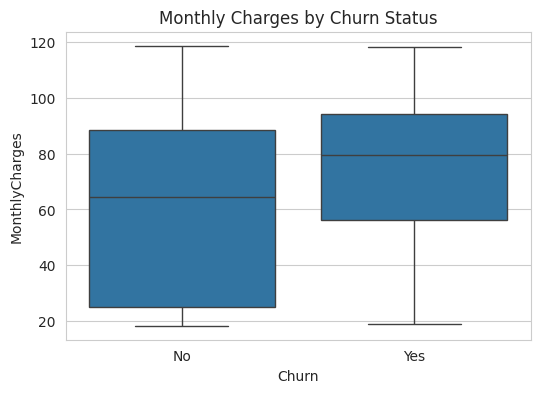

In [10]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges by Churn Status")
plt.show()

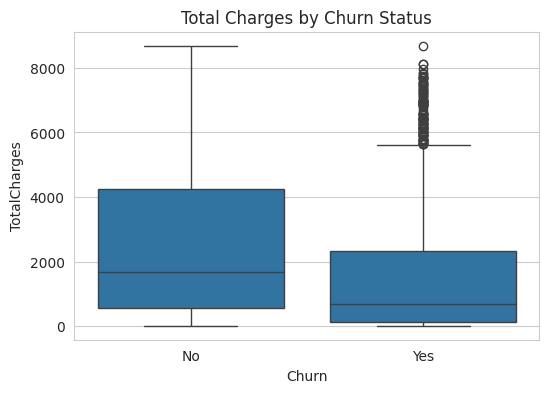

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Churn", y="TotalCharges")
plt.title("Total Charges by Churn Status")
plt.show()

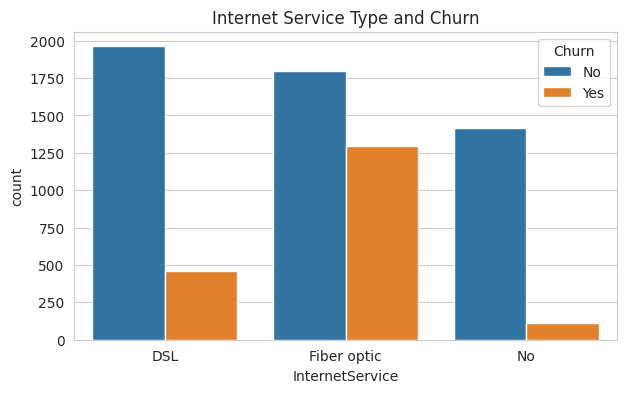

In [12]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x="InternetService", hue="Churn")
plt.title("Internet Service Type and Churn")
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────
# STEP 1 – Define target & features, then SPLIT FIRST
#          All preprocessing that learns from data happens AFTER
#          the split, so val/test information never leaks into training.
# ─────────────────────────────────────────────────────────────
y = df["Churn"].map({"Yes": 1, "No": 0})
X = df.drop("Churn", axis=1)

# First split: 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

# Second split: 50% of temp → val (10% total), 50% → test (10% total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"Train : {X_train.shape[0]:>5} rows  ({X_train.shape[0] / len(X) * 100:.1f}%)")
print(f"Val   : {X_val.shape[0]:>5} rows  ({X_val.shape[0]   / len(X) * 100:.1f}%)")
print(f"Test  : {X_test.shape[0]:>5} rows  ({X_test.shape[0]  / len(X) * 100:.1f}%)")
print()
print("Churn rate – Train:", round(y_train.mean(), 4),
      " Val:", round(y_val.mean(), 4),
      " Test:", round(y_test.mean(), 4))


In [ ]:
# ─────────────────────────────────────────────────────────────
# STEP 2 – Build preprocessing pipeline (will be fit on TRAIN only)
#
#   Numeric columns  : median imputation → StandardScaler
#   Categorical cols : most-frequent imputation → OneHotEncoder
#
# Using ColumnTransformer ensures the correct transformation is applied
# to each column type, and Pipeline chains them cleanly.
# ─────────────────────────────────────────────────────────────
numeric_cols     = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["str", "bool"]).columns.tolist()

print("Numeric columns   :", numeric_cols)
print("Categorical columns:", categorical_cols)

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler" , StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot" , OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

print("\nPreprocessing pipeline built.")


In [ ]:
# ─────────────────────────────────────────────────────────────
# STEP 3 – Hyperparameter tuning using the VALIDATION set
#
# For each model we try all combinations in the parameter grid.
# We fit on X_train, then compute all 4 metrics on both train and val:
#   - Train metrics reveal whether a model is overfitting.
#   - Val metrics are used to select the best parameters.
#
# Selection rule (transparent, tie-break chain):
#   1) Highest Val F1  (balances precision & recall; good for imbalanced data)
#   2) Highest Val Recall  (we prefer not to miss churners)
#   3) Highest Val Accuracy
#
# The test set is NEVER touched in this step.
# ─────────────────────────────────────────────────────────────

def eval_metrics(y_true, y_pred):
    """Return dict with Accuracy, Precision, Recall, F1."""
    return {
        "Accuracy" : accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall"   : recall_score(y_true, y_pred, zero_division=0),
        "F1"       : f1_score(y_true, y_pred, zero_division=0),
    }

def make_model(name, params):
    """Instantiate a classifier by name with the given hyperparameters."""
    if name == "Logistic Regression":
        return LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, **params)
    elif name == "Decision Tree":
        return DecisionTreeClassifier(random_state=RANDOM_STATE, **params)
    elif name == "Random Forest":
        return RandomForestClassifier(random_state=RANDOM_STATE, **params)

# ── Parameter grids ──────────────────────────────────────────
# Logistic Regression: regularisation strength C, class weighting
# Decision Tree      : tree depth + leaf / split size limits (prevent overfitting)
# Random Forest      : number of trees, depth, leaf size
param_grids = {
    "Logistic Regression": {
        "C"           : [0.01, 0.1, 1, 10],
        "class_weight": [None, "balanced"],
    },
    "Decision Tree": {
        "max_depth"        : [3, 5, 10, None],
        "min_samples_leaf" : [1, 5, 20],
        "min_samples_split": [2, 10, 20],
    },
    "Random Forest": {
        "n_estimators"    : [50, 100, 200],
        "max_depth"       : [5, 10, None],
        "min_samples_leaf": [1, 5, 10],
    },
}

# ── Run grid search ──────────────────────────────────────────
best_per_model = {}   # model_name → best result row (dict)

for model_name, grid in param_grids.items():
    print(f"\n{'='*65}")
    print(f"  Tuning: {model_name}")
    print(f"{'='*65}")

    keys   = list(grid.keys())
    values = list(grid.values())
    rows   = []

    for combo in itertools.product(*values):
        params = dict(zip(keys, combo))

        # Build a full pipeline: preprocessor + model
        pipe = Pipeline([
            ("preprocessor", preprocessor),
            ("classifier"  , make_model(model_name, params))
        ])
        pipe.fit(X_train, y_train)   # fit on TRAIN only

        train_m = eval_metrics(y_train, pipe.predict(X_train))
        val_m   = eval_metrics(y_val,   pipe.predict(X_val))

        rows.append({
            "Model"   : model_name,
            "Params"  : params,
            "pipeline": pipe,          # keep fitted pipeline (Scheme A: train-only)
            **{f"Train_{k}": v for k, v in train_m.items()},
            **{f"Val_{k}"  : v for k, v in val_m.items()},
        })

    # Sort by Val F1 (desc), then Val Recall, then Val Accuracy
    rows.sort(
        key=lambda r: (r["Val_F1"], r["Val_Recall"], r["Val_Accuracy"]),
        reverse=True
    )

    # Display top-5 combinations
    print(f"\nTop 5 combinations (sorted by Val F1 ↓):")
    print(f"{'Params':<62} {'TrF1':>6} {'ValF1':>6} {'ValRec':>7} {'ValAcc':>7}")
    print("-" * 90)
    for r in rows[:5]:
        print(
            f"{str(r['Params']):<62} "
            f"{r['Train_F1']:>6.4f} "
            f"{r['Val_F1']:>6.4f} "
            f"{r['Val_Recall']:>7.4f} "
            f"{r['Val_Accuracy']:>7.4f}"
        )

    best = rows[0]
    best_per_model[model_name] = best

    print(f"\n★ Best params : {best['Params']}")
    print(
        f"  Train → Acc={best['Train_Accuracy']:.4f}  "
        f"Prec={best['Train_Precision']:.4f}  "
        f"Rec={best['Train_Recall']:.4f}  "
        f"F1={best['Train_F1']:.4f}"
    )
    print(
        f"  Val   → Acc={best['Val_Accuracy']:.4f}  "
        f"Prec={best['Val_Precision']:.4f}  "
        f"Rec={best['Val_Recall']:.4f}  "
        f"F1={best['Val_F1']:.4f}"
    )


In [ ]:
# ─────────────────────────────────────────────────────────────
# STEP 4 – Select the best model across all three families
# ─────────────────────────────────────────────────────────────
summary = [
    {
        "Model"          : name,
        "Best Params"    : row["Params"],
        "Train Accuracy" : row["Train_Accuracy"],
        "Train Precision": row["Train_Precision"],
        "Train Recall"   : row["Train_Recall"],
        "Train F1"       : row["Train_F1"],
        "Val Accuracy"   : row["Val_Accuracy"],
        "Val Precision"  : row["Val_Precision"],
        "Val Recall"     : row["Val_Recall"],
        "Val F1"         : row["Val_F1"],
    }
    for name, row in best_per_model.items()
]

summary_df = pd.DataFrame(summary)
print("Best configuration per model (Train vs Val metrics):")
display(summary_df[[
    "Model",
    "Train Accuracy", "Train Precision", "Train Recall", "Train F1",
    "Val Accuracy",   "Val Precision",   "Val Recall",   "Val F1"
]])

# Apply selection rule: Val F1 → Val Recall → Val Accuracy
summary.sort(
    key=lambda r: (r["Val F1"], r["Val Recall"], r["Val Accuracy"]),
    reverse=True
)

best_overall    = summary[0]
best_model_name = best_overall["Model"]
best_params     = best_overall["Best Params"]

print(f"\n★ Selected best model  : {best_model_name}")
print(f"  Best hyperparameters : {best_params}")
print(f"  Selection rule       : highest Val F1; "
      f"tie-break → Val Recall → Val Accuracy")
print(
    f"  Val F1={best_overall['Val F1']:.4f}  "
    f"Val Recall={best_overall['Val Recall']:.4f}  "
    f"Val Accuracy={best_overall['Val Accuracy']:.4f}"
)


In [ ]:
# ─────────────────────────────────────────────────────────────
# STEP 5 – Final evaluation on TEST set  (evaluated only ONCE)
#
# We use the pipeline that was already fitted on the training set
# (Scheme A: fit on train only – no refit on train+val).
# ─────────────────────────────────────────────────────────────
best_pipeline = best_per_model[best_model_name]["pipeline"]
y_pred_test   = best_pipeline.predict(X_test)

test_m = eval_metrics(y_test, y_pred_test)

print("\n" + "=" * 60)
print(f"  FINAL TEST RESULTS  –  {best_model_name}")
print("=" * 60)
print(f"  Accuracy : {test_m['Accuracy']:.4f}")
print(f"  Precision: {test_m['Precision']:.4f}")
print(f"  Recall   : {test_m['Recall']:.4f}")
print(f"  F1 Score : {test_m['F1']:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title(f"Confusion Matrix – {best_model_name} (Test Set)")
plt.tight_layout()
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_test, y_pred_test,
    target_names=["No Churn", "Churn"]
))


In [ ]:
# ─────────────────────────────────────────────────────────────
# Feature Importance – Random Forest (best params from tuning)
# ─────────────────────────────────────────────────────────────
rf_pipe = best_per_model["Random Forest"]["pipeline"]
rf_clf  = rf_pipe.named_steps["classifier"]

# Retrieve feature names produced by the preprocessing pipeline
ohe               = (rf_pipe
                       .named_steps["preprocessor"]
                       .named_transformers_["cat"]
                       .named_steps["onehot"])
cat_feature_names = ohe.get_feature_names_out(categorical_cols).tolist()
all_feature_names = numeric_cols + cat_feature_names

feature_importance = pd.DataFrame({
    "Feature"   : all_feature_names,
    "Importance": rf_clf.feature_importances_
}).sort_values("Importance", ascending=False)

print("Top 10 most important features (Random Forest, best params):")
display(feature_importance.head(10))

top10 = feature_importance.head(10)
plt.figure(figsize=(8, 5))
sns.barplot(data=top10, x="Importance", y="Feature")
plt.title("Top 10 Important Features – Random Forest (Best Params)")
plt.tight_layout()
plt.show()
